# অধ্যায় ৫: মডেল মূল্যায়ন
## পাঠ ৫.৪: প্রিসিশন-রিকল ও ROC

আজ আমরা শিখব প্রিসিশন-রিকল কার্ভ এবং ROC কার্ভ সম্পর্কে। এই দুটি গ্রাফিক্যাল টুল মডেলের পারফরম্যান্স বুঝতে আমাদের সাহায্য করে।

### A. গল্প: নিরাপত্তা প্রহরী

তুমি একটি বড় ভবনের নিরাপত্তা প্রহরী। তুমি সন্দেহভাজন ব্যক্তিদের চিহ্নিত করতে একটি মেশিন লার্নিং মডেল ব্যবহার করছ। মডেলটি প্রতিটি ব্যক্তিকে একটি 'স্কোর' দেয়—০ (একদম নিরাপদ) থেকে ১ (অত্যন্ত সন্দেহজনক)।

- যদি তুমি থ্রেশহোল্ড ০.৯ সেট করো—শুধু খুব সন্দেহজনকদের ধরা হবে। Precision বেশি হবে কিন্তু Recall কম।
- যদি তুমি থ্রেশহোল্ড ০.১ সেট করো—প্রায় সবাইকে ধরা হবে। Recall বেশি হবে কিন্তু Precision কম।

প্রিসিশন-রিকল কার্ভ এবং ROC কার্ভ আমাদের থ্রেশহোল্ড পরিবর্তনের সাথে সাথে কী হয় সেটা বুঝতে সাহায্য করে।

### B. প্রিসিশন-রিকল কার্ভ

প্রিসিশন-রিকল কার্ভ বিভিন্ন থ্রেশহোল্ডে Precision এবং Recall-এর সম্পর্ক দেখায়। সাধারণত Precision বাড়লে Recall কমে, এবং উল্টোটাও সত্যি।

**কখন ব্যবহার করব?** যখন ডেটা ইমব্যালেন্সড বা পজিটিভ ক্লাস বেশি গুরুত্বপূর্ণ।

### C. ROC কার্ভ

ROC (Receiver Operating Characteristic) কার্ভ True Positive Rate (Recall) এবং False Positive Rate-এর সম্পর্ক দেখায়।

- **True Positive Rate (TPR):** Recall-এর সমান = TP/(TP+FN)
- **False Positive Rate (FPR):** FP/(FP+TN)—অর্থাৎ, সুস্থ ব্যক্তিদের কতজনকে ভুল করে রোগী বলা হচ্ছে

একটি নিখুঁত মডেলের ROC কার্ভ উপরের বাম কোণ দিয়ে যাবে। একটি এলোমেলো মডেলের ROC কার্ভ হবে কর্ণ (Diagonal)।

### D. AUC (Area Under the Curve)

AUC হচ্ছে ROC কার্ভের নিচের ক্ষেত্রফল।
- AUC = ১.০: নিখুঁত মডেল
- AUC = ০.৫: এলোমেলো মডেল (কাজেই না করলেও চলে)
- AUC > ০.৮: খুব ভালো মডেল

AUC-র সুবিধা হলো এটি একটি সংখ্যা যা থ্রেশহোল্ড-ইনডিপেন্ডেন্ট—অর্থাৎ, কোনো নির্দিষ্ট থ্রেশহোল্ডের ওপর নির্ভর করে না।

In [1]:
# প্রয়োজনীয় লাইব্রেরি
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.metrics import (
    PrecisionRecallDisplay, RocCurveDisplay,
    precision_recall_curve, roc_curve, auc,
    average_precision_score, roc_auc_score
)

# ইমব্যালেন্সড ডেটাসেট
X, y = make_classification(
    n_samples=2000, n_features=10, n_informative=5,
    n_redundant=2, weights=[0.8, 0.2], random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print('ডেটা প্রস্তুত:', X_train.shape[0], 'ট্রেন,', X_test.shape[0], 'টেস্ট')

ডেটা প্রস্তুত: 1400 ট্রেন, 600 টেস্ট


### E. প্রিসিশন-রিকল কার্ভ প্লট

এখন আমরা Logistic Regression, Random Forest এবং KNN-এর জন্য প্রিসিশন-রিকল কার্ভ প্লট করব।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserW

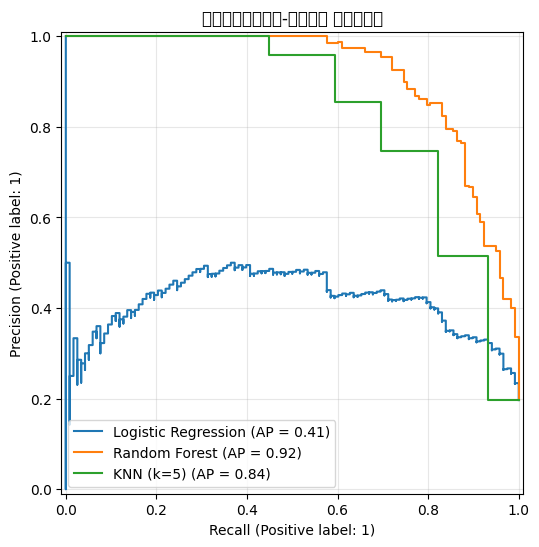

In [2]:
# তিনটি ক্লাসিফায়ার ট্রেইন করি
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)

# প্রিসিশন-রিকল কার্ভ
fig, ax = plt.subplots(figsize=(10, 6))

for name, clf in classifiers.items():
    PrecisionRecallDisplay.from_estimator(
        clf, X_test, y_test, name=name, ax=ax
    )

ax.set_title('প্রিসিশন-রিকল কার্ভ')
ax.grid(True, alpha=0.3)
plt.show()

### F. ROC কার্ভ প্লট

ROC কার্ভ বিভিন্ন থ্রেশহোল্ডে TPR (Recall) বনাম FPR দেখায়। একটি ভালো মডেলের ROC কার্ভ উপরের দিকে বাঁকা হবে।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: Use

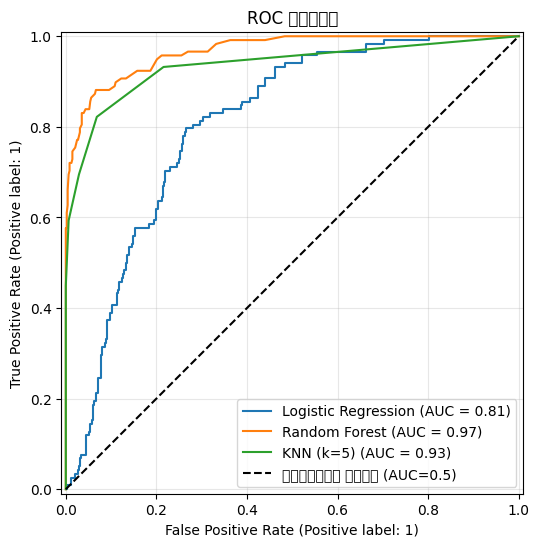

In [3]:
# ROC কার্ভ
fig, ax = plt.subplots(figsize=(10, 6))

for name, clf in classifiers.items():
    RocCurveDisplay.from_estimator(
        clf, X_test, y_test, name=name, ax=ax
    )

# এলোমেলো মডেলের লাইন (AUC = 0.5)
ax.plot([0, 1], [0, 1], 'k--', label='এলোমেলো মডেল (AUC=0.5)')
ax.set_title('ROC কার্ভ')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### G. AUC স্কোর তুলনা

এখন আমরা প্রতিটি মডেলের জন্য ROC-AUC এবং প্রিসিশন-রিকল AUC (Average Precision) সংখ্যায় দেখি।

In [4]:
# AUC স্কোর
print(f'{"মডেল":25s} {"ROC-AUC":12s} {"Avg Precision":15s} {"Accuracy":12s}')
print('-' * 64)

for name, clf in classifiers.items():
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    
    rocauc = roc_auc_score(y_test, y_prob)
    avg_prec = average_precision_score(y_test, y_prob)
    acc = clf.score(X_test, y_test)
print(f'{name:25s} {rocauc:12.4f} {avg_prec:15.4f} {acc:12.4f}')
print('\n→ ROC-AUC থ্রেশহোল্ড-ইনডিপেন্ডেন্ট—এটা মডেলের সামগ্রিক গুণমান দেখায়')
print('→ Avg Precision প্রিসিশন-রিকল কার্ভের নিচের ক্ষেত্রফল—ইমব্যালেন্সড ডেটার জন্য ভালো')

মডেল                      ROC-AUC      Avg Precision   Accuracy    
----------------------------------------------------------------
KNN (k=5)                       0.9347          0.8390       0.9167

→ ROC-AUC থ্রেশহোল্ড-ইনডিপেন্ডেন্ট—এটা মডেলের সামগ্রিক গুণমান দেখায়
→ Avg Precision প্রিসিশন-রিকল কার্ভের নিচের ক্ষেত্রফল—ইমব্যালেন্সড ডেটার জন্য ভালো


### H. নিজে হাতে করে দেখা: ডিসিশন থ্রেশহোল্ড

এখন আমরা Logistic Regression-এর জন্য বিভিন্ন থ্রেশহোল্ডে কী হয় সেটা দেখব।

In [5]:
# বিভিন্ন থ্রেশহোল্ডে Precision, Recall
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_prob = lr.predict_proba(X_test)[:, 1]

thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
print(f'{"থ্রেশহোল্ড":12s} {"Precision":12s} {"Recall":12s} {"F1":12s}')
print('-' * 48)

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
print(f'{t:12.1f} {prec:12.4f} {rec:12.4f} {f1:12.4f}')
print('\n→ থ্রেশহোল্ড 0.1: Recall বেশি, Precision কম (সবাইকে পজিটিভ বলার ঝোঁক)')
print('→ থ্রেশহোল্ড 0.9: Precision বেশি, Recall কম (শুধু নিশ্চিতদের পজিটিভ বলে)')

থ্রেশহোল্ড   Precision    Recall       F1          
------------------------------------------------


         0.9       0.5000       0.0085       0.0167

→ থ্রেশহোল্ড 0.1: Recall বেশি, Precision কম (সবাইকে পজিটিভ বলার ঝোঁক)
→ থ্রেশহোল্ড 0.9: Precision বেশি, Recall কম (শুধু নিশ্চিতদের পজিটিভ বলে)


### I. Iris ডেটাসেটে ROC (One-vs-Rest)

মাল্টি-ক্লাস ডেটার জন্যও ROC প্লট করা যায়। Iris-এ ৩টি ক্লাস। আমরা One-vs-Rest পদ্ধতি ব্যবহার করব—অর্থাৎ, প্রতিটি ক্লাসের জন্য আলাদা ROC।

In [6]:
# মাল্টি-ক্লাসের বদলে বাইনারি ক্লাসিফিকেশন ব্যবহার করি
from sklearn.datasets import make_classification

# বাইনারি ক্লাসিফিকেশন ডেটাসেট
X_bin, y_bin = make_classification(
    n_samples=300, n_features=5, n_informative=3,
    n_redundant=1, random_state=42
)
X_tr, X_te, y_tr, y_te = train_test_split(X_bin, y_bin, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tr, y_tr)

# Precision-Recall Curve
from sklearn.metrics import PrecisionRecallDisplay


### J. ROC vs প্রিসিশন-রিকল: কখন কী?

| বৈশিষ্ট্য | ROC (AUC) | প্রিসিশন-রিকল (AP) |
|-----------|-----------|-------------------|
| ব্যালেন্সড ডেটা | ভালো কাজ করে | ভালো কাজ করে |
| ইমব্যালেন্সড ডেটা | অতিরঞ্জিত দেখাতে পারে | বাস্তবসম্মত দেখায় |
| নেগেটিভ ক্লাস বড় হলে | FPR ছোট হয়, AUC বেশি দেখায় | প্রভাবিত হয় না |
| ব্যাখ্যা | সহজ, বহুল ব্যবহৃত | একটু জটিল |
| পজিটিভ ক্লাস বিরল | সাবধান | সেরা পছন্দ |

### K. তুমি কি বুঝতে পেরেছ?

**প্রশ্ন ১:** ROC কার্ভের X এবং Y অক্ষ কী কী?

**প্রশ্ন ২:** AUC = ০.৫ মানে কী?

**প্রশ্ন ৩:** প্রিসিশন-রিকল কার্ভ কখন ROC-র চেয়ে বেশি উপযোগী?

**প্রশ্ন ৪:** থ্রেশহোল্ড কমানোর সাথে Precision এবং Recall-এর কী পরিবর্তন হয়?

### L. সারসংক্ষেপ

আজ আমরা শিখলাম:
✅ প্রিসিশন-রিকল কার্ভ Precision ও Recall-এর ট্রেড-অফ দেখায়
✅ ROC কার্ভ TPR (Recall) বনাম FPR দেখায়
✅ AUC মডেলের থ্রেশহোল্ড-ইনডিপেন্ডেন্ট গুণমান মাপে
✅ AUC ০.৫ = এলোমেলো, AUC ১.০ = নিখুঁত
✅ ইমব্যালেন্সড ডেটায় প্রিসিশন-রিকল ROC-র চেয়ে বাস্তবসম্মত
✅ মাল্টি-ক্লাস ডেটার জন্য One-vs-Rest ROC ব্যবহার করা যায়

এভাবে আমরা অধ্যায় ৫ শেষ করলাম। পরবর্তী অধ্যায়ে আমরা পাইপলাইন নিয়ে শিখব!